In [1]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project


# Import and setup

In [2]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

Connected to RFSoC at 192.168.0.103


In [3]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500
default_config.readout_integration_tus = 213  # max ~106.7 µs; auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout int.:    {default_config.readout_integration_tus:.2f} µs  ({default_config.readout_integration_treg} treg)")

Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         5000
  Relax delay:     501 ns
  Readout int.:    213.00 µs  (65434 treg)


# ODMR

In [8]:
# =============================================================================
# ODMR sweep — edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV (MW on / MW off / contrast).
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
import importlib

from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 10500              # 0–32767; ↑ if contrast weak, ↓ if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 10                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 500     # delay register units between MW on/off segments 100000 

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS = 213   # or set e.g. 50.0 (microseconds)

# --- Frequency sweep (MHz) ---
MW_FREQ_START_MHZ = 2600
MW_FREQ_STOP_MHZ = 3100
MW_FREQ_STEP_MHZ = 1             # step size (MHz); narrow range once peaks are known
# Instead of delta, you can use a fixed point count, e.g.:
#   config_odmr.add_linear_sweep("mw", "fMHz", start=2700, stop=3000, nsweep_points=301)
# (then comment out the add_linear_sweep call in the build block below and paste there)

# --- CSV export ---
SAVE_ODMR_CSV = True             # set False to only acquire (still defines d, prog_odmr for plots)

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} → {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = Path.cwd() / f"odmr_sweep_{ts}.csv"
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows → {csv_path.resolve()}")
    display(FileLink(csv_path.name))


Requested 2600 to 3100 by 1
Instead using 2600.00000038147 to 3099.9998096466065 by 0.9999996185302735 in 501 steps
ODMR configuration:
  ADC channel: 0  MW channel: 1  gain: 10500
  Sweep: 2600.000 → 3100.000 MHz  (501 pts)
  reps: 10  est. time: 2.2 s


  0%|          | 0/5010 [00:00<?, ?it/s]

Acquisition done.
CSV: 501 rows → /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/Modules/odmr_sweep_20260507_133443.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/Modules/odmr_sweep_20260507_133443.csv

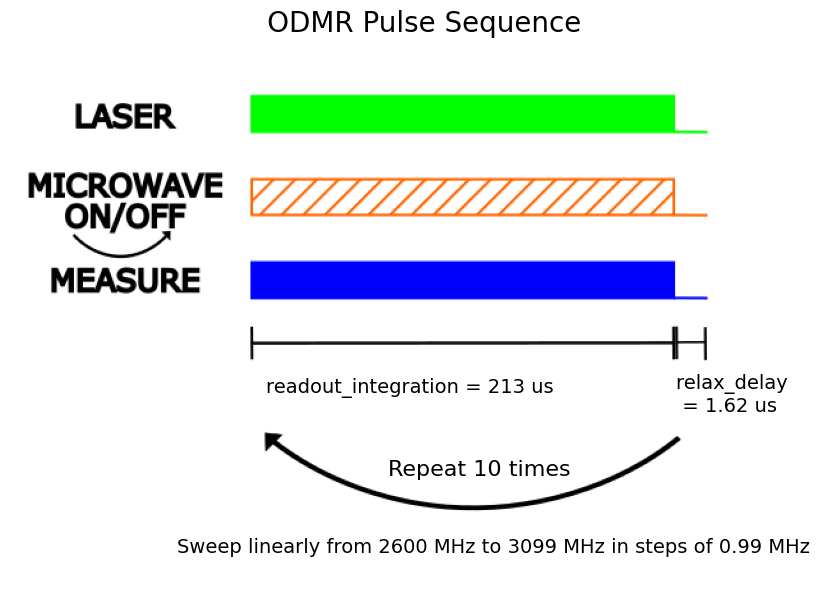

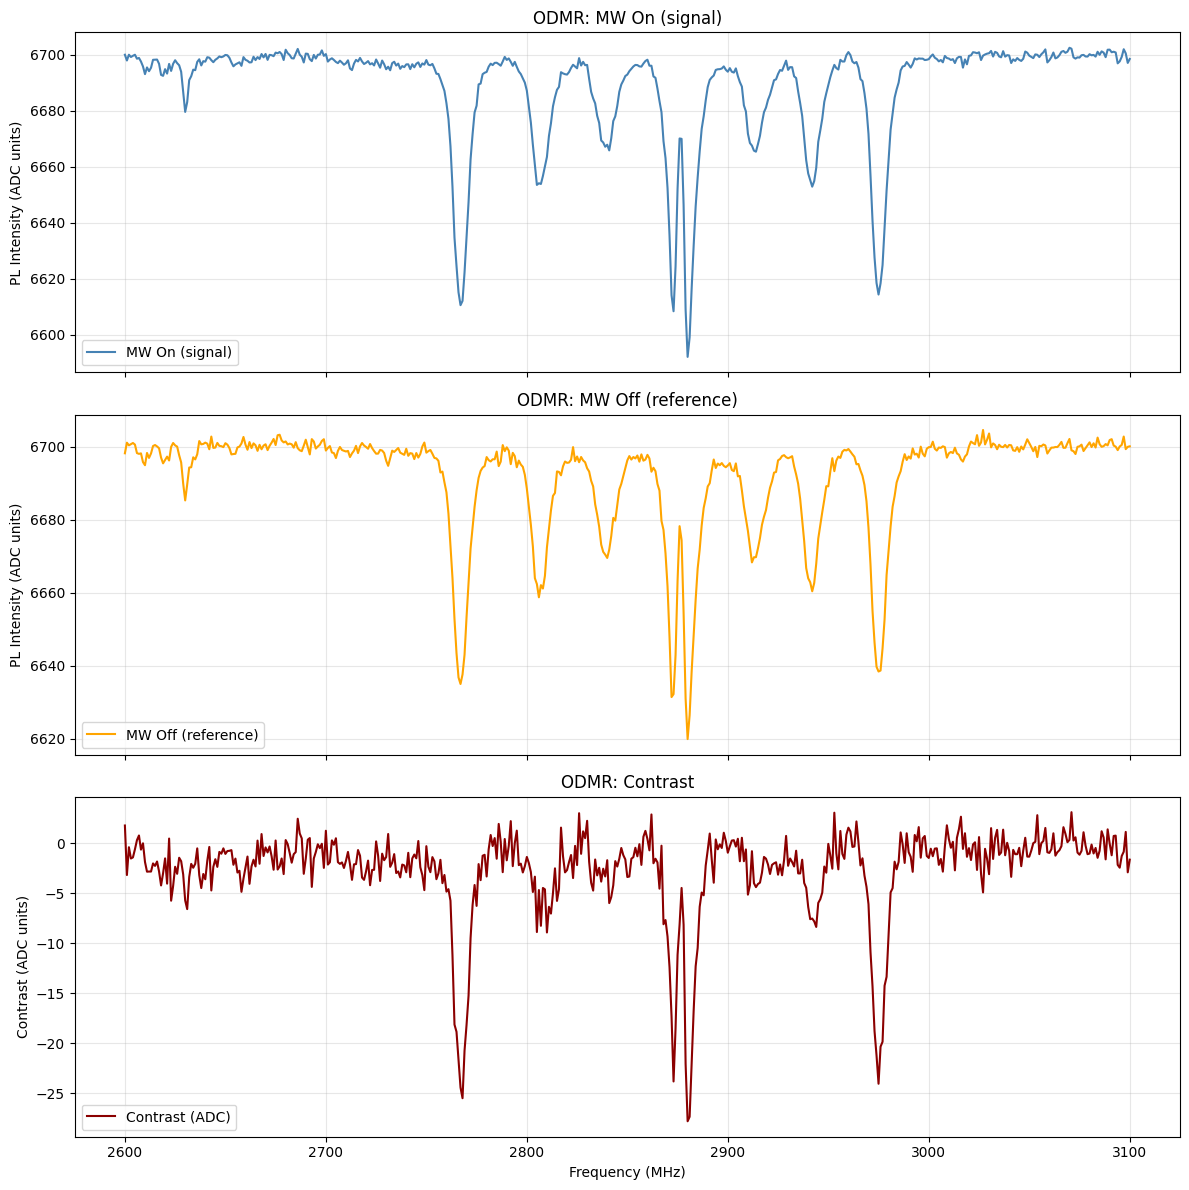

In [9]:
qd.LockinODMR.plot_sequence(config_odmr)

# Plot ODMR spectrum with subplots for MW On, MW Off, and Contrast
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot MW On (signal)
axes[0].plot(d.frequencies, d.signal, label='MW On (signal)', color='steelblue')
axes[0].set_ylabel('PL Intensity (ADC units)')
axes[0].set_title('ODMR: MW On (signal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MW Off (reference)
axes[1].plot(d.frequencies, d.reference, label='MW Off (reference)', color='orange')
axes[1].set_ylabel('PL Intensity (ADC units)')
axes[1].set_title('ODMR: MW Off (reference)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Contrast
axes[2].plot(d.frequencies, d.contrast, label='Contrast (ADC)', color='darkred')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Contrast (ADC units)')
axes[2].set_title('ODMR: Contrast')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

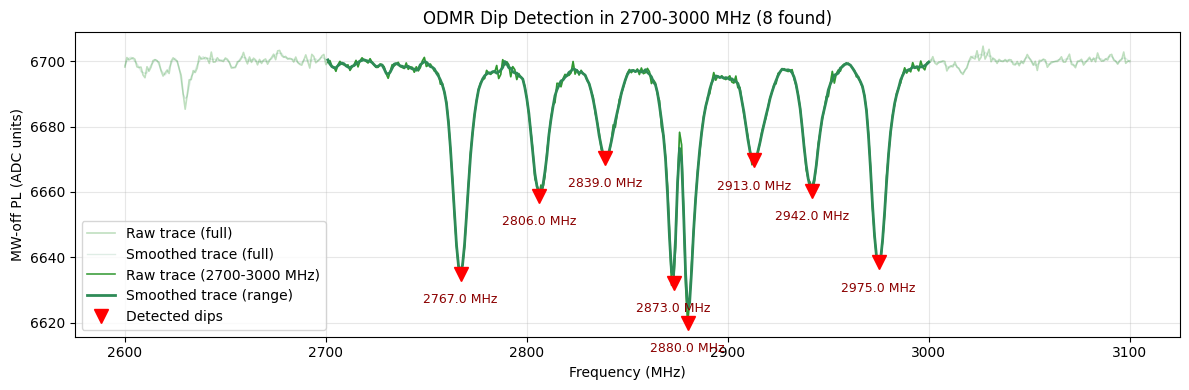

Trace source: Current acquisition (`d.reference`)
Analyzed range: 2700 to 3000 MHz
Using column 1 as x and column 3 as y when a CSV path is provided.
Prominence threshold used: 6.62 ADC
Detected ODMR dips in selected range:
  Dip 1: 2767.00 MHz  (6635.0297 ADC)
  Dip 2: 2806.00 MHz  (6658.7668 ADC)
  Dip 3: 2839.00 MHz  (6670.4441 ADC)
  Dip 4: 2873.00 MHz  (6632.2514 ADC)
  Dip 5: 2880.00 MHz  (6619.9502 ADC)
  Dip 6: 2913.00 MHz  (6669.7245 ADC)
  Dip 7: 2942.00 MHz  (6660.4095 ADC)
  Dip 8: 2975.00 MHz  (6638.4430 ADC)
Suggested resonance frequency (deepest dip in range): 2880.00 MHz


In [10]:
# Detect and mark ODMR dips from frequency (column 1) vs MW-off PL (column 3)
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter

ODMR_CSV_PATH = None
# ODMR_CSV_PATH = Path("/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/odmr_sweep_20260320_132708.csv")
# Set ODMR_CSV_PATH to a saved CSV to analyze first-column frequency vs third-column PL.
# Leave it as None to analyze the current in-memory sweep (`d.reference`).


def load_odmr_trace(csv_path=None):
    if csv_path is None:
        return (
            np.asarray(d.frequencies, dtype=float),
            np.asarray(d.reference, dtype=float),
            'MW-off reference',
            'Current acquisition (`d.reference`)'
        )

    odmr_df = pd.read_csv(Path(csv_path))
    if {'frequency_MHz', 'photoluminescence_mw_off_ADC'}.issubset(odmr_df.columns):
        x = odmr_df['frequency_MHz'].to_numpy(dtype=float)
        y = odmr_df['photoluminescence_mw_off_ADC'].to_numpy(dtype=float)
        y_label = 'photoluminescence_mw_off_ADC'
    else:
        x = odmr_df.iloc[:, 0].to_numpy(dtype=float)
        y = odmr_df.iloc[:, 2].to_numpy(dtype=float)
        y_label = odmr_df.columns[2]

    return x, y, y_label, str(Path(csv_path).resolve())


def find_odmr_dips(
    frequencies,
    signal,
    n_dips=4,
    prominence_factor=0.4,
    min_prominence=6.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=None,
    freq_max=None,
):
    """Find ODMR transmission dips (local minima) in the selected PL trace within a frequency range."""
    x = np.asarray(frequencies, dtype=float)
    y = np.asarray(signal, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Limit analysis to within freq_min and freq_max if given
    if freq_min is not None or freq_max is not None:
        idx_range = np.ones_like(x, dtype=bool)
        if freq_min is not None:
            idx_range &= x >= freq_min
        if freq_max is not None:
            idx_range &= x <= freq_max
        x = x[idx_range]
        y = y[idx_range]

    if len(x) < 5:
        raise ValueError('Need at least 5 finite points to detect ODMR dips.')

    w = int(max(5, smooth_window))
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        w = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if w < polyorder + 2:
        y_smooth = y.copy()
    else:
        y_smooth = savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 2), mode='interp')

    trend = np.polyval(np.polyfit(x, y_smooth, 1), x)
    y_detr = y_smooth - trend

    prominence = max(float(min_prominence), np.std(y_detr) * float(prominence_factor))
    dip_idx, props = scipy_find_peaks(
        -y_detr,
        prominence=prominence,
        distance=max(1, int(min_distance_pts)),
    )

    if len(dip_idx) == 0:
        return dip_idx, y_smooth, y_detr, props, prominence, x, y

    prom_arr = props.get('prominences', np.zeros(len(dip_idx), dtype=float))
    keep = np.argsort(prom_arr)[-int(n_dips):]
    dip_idx = dip_idx[keep]
    dip_idx = dip_idx[np.argsort(x[dip_idx])]
    return dip_idx, y_smooth, y_detr, props, prominence, x, y


# Restrict frequency range for dip detection: 2700 to 3000 MHz
FREQ_MIN = 2700
FREQ_MAX = 3000

frequencies, trace, trace_label, trace_source = load_odmr_trace(ODMR_CSV_PATH)
dip_idx, trace_smooth, trace_detr, dip_props, used_prominence, x_range, y_range = find_odmr_dips(
    frequencies,
    trace,
    n_dips=8,
    prominence_factor=0.4,
    min_prominence=4.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=FREQ_MIN,
    freq_max=FREQ_MAX,
)

plt.figure(figsize=(12, 4))

# Plot full raw and smoothed traces for visual context
plt.plot(frequencies, trace, color='green', linewidth=1.2, alpha=0.25, label='Raw trace (full)')
plt.plot(frequencies, savgol_filter(trace, window_length=7 if len(trace) > 7 else 5, polyorder=2 if len(trace) > 2 else 1, mode='interp'), color='seagreen', linewidth=1.0, alpha=0.15, label='Smoothed trace (full)')

# Plot zoomed-in range (2700-3000)
plt.plot(x_range, y_range, color='green', linewidth=1.2, alpha=0.75, label=f'Raw trace ({FREQ_MIN}-{FREQ_MAX} MHz)')
plt.plot(x_range, trace_smooth, color='seagreen', linewidth=2.0, label='Smoothed trace (range)')

if len(dip_idx) > 0:
    plt.plot(x_range[dip_idx], y_range[dip_idx], 'rv', markersize=10, label='Detected dips')
    for i, idx in enumerate(dip_idx):
        plt.annotate(
            f"{x_range[idx]:.1f} MHz",
            xy=(x_range[idx], y_range[idx]),
            xytext=(0, -14),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=9,
            color='darkred',
        )

plt.ylabel('MW-off PL (ADC units)' if trace_label == 'MW-off reference' else trace_label)
plt.xlabel('Frequency (MHz)')
plt.title(f'ODMR Dip Detection in {FREQ_MIN}-{FREQ_MAX} MHz ({len(dip_idx)} found)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Trace source: {trace_source}')
print(f'Analyzed range: {FREQ_MIN} to {FREQ_MAX} MHz')
print('Using column 1 as x and column 3 as y when a CSV path is provided.')
print(f'Prominence threshold used: {used_prominence:.2f} ADC')

if len(dip_idx) == 0:
    print('No ODMR dips found in the specified range. Lower `min_prominence` or reduce `smooth_window`.')
else:
    print('Detected ODMR dips in selected range:')
    for i, idx in enumerate(dip_idx):
        print(f"  Dip {i+1}: {x_range[idx]:.2f} MHz  ({y_range[idx]:.4f} ADC)")

    deepest_idx = dip_idx[np.argmin(y_range[dip_idx])]
    print(f'Suggested resonance frequency (deepest dip in range): {x_range[deepest_idx]:.2f} MHz')


# Lockin

## Generate 16 parked frequencies

ODMR source: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/Modules/odmr_sweep_20260507_133443.csv
Parked plan written to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parked_plan_odmr_sweep_20260507_133443.csv
Number of parked frequencies: 16
Estimated bias field (mT): -2.1431, -2.5571, 3.4053


,block_index,transition_index,center_mhz,linewidth_mhz,f_minus_mhz,f_plus_mhz,slope_minus_per_mhz,slope_plus_per_mhz
0,1,0,2629.999991,4.000000,2628.999989,2630.999989,-0.001069,0.000847
1,2,1,2767.160070,10.176068,2762.999938,2770.999935,-0.002439,0.002049
2,3,2,2806.657275,4.310308,2803.999923,2808.999921,-0.001069,0.000509
3,4,3,2840.999904,4.000001,2837.999910,2841.999908,-0.000167,0.000782
4,5,4,2880.545287,3.446467,2877.999894,2881.999893,-0.004554,0.002433
5,6,5,2880.545287,3.446467,2877.999894,2881.999893,-0.004554,0.002433
6,7,6,2941.999870,4.000000,2938.999871,2943.999869,-0.000941,0.001043
7,8,7,2975.222481,7.838056,2970.999859,2977.999856,-0.002310,0.001984


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parked_plan_odmr_sweep_20260507_133443.csv

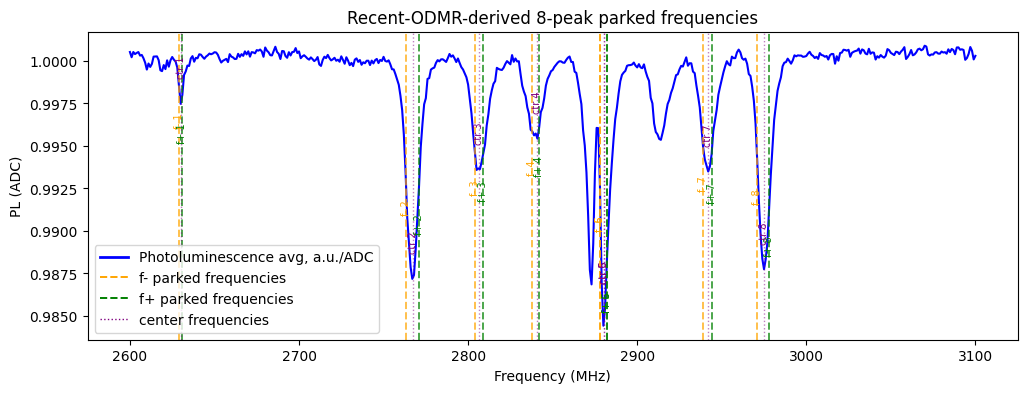

In [11]:
# Step 1 — Generate the parked frequencies from the most recent ODMR sweep, and plot them on the current ODMR spectrum.

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# Locate NV_Magnetometry_Software-main (sibling to NV Compact Magnetometer/Initial Test).
_search_roots = [Path.cwd(), *Path.cwd().parents]
NV_REPO_DIR = None
for _root in _search_roots:
    candidate = _root / "NV_Magnetometry_Software-main"
    if (candidate / "nv_toolkit" / "operator_cli.py").exists():
        NV_REPO_DIR = candidate
        break
if NV_REPO_DIR is None:
    raise FileNotFoundError("NV_Magnetometry_Software-main not found relative to notebook directory")
if str(NV_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(NV_REPO_DIR))

from nv_toolkit.tui import (
    _load_operator_full_scan,
    _suggest_parked_frequencies,
    _write_parked_plan_csv,
    _estimate_bias_field_mT,
)

# Pick the ODMR CSV. Default: the one saved by the ODMR cell above (LAST_ODMR_CSV).
if "LAST_ODMR_CSV" not in globals():
    raise RuntimeError("Run the ODMR sweep cell first to set LAST_ODMR_CSV")
ODMR_CSV_FOR_PLAN = Path(LAST_ODMR_CSV)

# Restrict peak-finding scope to a frequency window (set to None for full range).
# The window applies AFTER nv_toolkit detects transitions on the full spectrum:
# we keep only transitions whose centers fall inside [low, high] MHz.
# nv_toolkit's slope/baseline computation still uses the full spectrum so
# slopes near the window edges are accurate.
PARKED_FREQ_RANGE_MHZ = (2700.0, 3050.0)   # set to None to use all detected transitions

freqs_mhz, measured, transition_centers = _load_operator_full_scan(ODMR_CSV_FOR_PLAN, "auto")

# Apply the frequency-range filter (if any) to the detected transitions.
if PARKED_FREQ_RANGE_MHZ is not None:
    _low, _high = float(PARKED_FREQ_RANGE_MHZ[0]), float(PARKED_FREQ_RANGE_MHZ[1])
    _in_range = (transition_centers >= _low) & (transition_centers <= _high)
    _n_total = len(transition_centers)
    transition_centers = transition_centers[_in_range]
    print(f"Parked-freq search restricted to {_low:.0f}-{_high:.0f} MHz: "
          f"kept {len(transition_centers)} of {_n_total} detected transitions.")
    if len(transition_centers) == 0:
        raise RuntimeError(
            f"No transitions fall in {_low:.0f}-{_high:.0f} MHz. "
            f"Either widen PARKED_FREQ_RANGE_MHZ or set it to None."
        )

parked_plan = _suggest_parked_frequencies(freqs_mhz, measured, transition_centers)

# Persist the plan as the canonical handoff CSV.
PARKED_PLAN_CSV = (PROJECT_ROOT / "data" / "lockin_multipoint" / f"parked_plan_{ODMR_CSV_FOR_PLAN.stem}.csv")
PARKED_PLAN_CSV.parent.mkdir(parents=True, exist_ok=True)
_write_parked_plan_csv(PARKED_PLAN_CSV, parked_plan)

# Try to estimate the bias field; fall back to None if fitting fails.
# Bias estimation uses the (possibly filtered) transition centers — make sure
# enough transitions remain or the fit may be ill-conditioned.
try:
    BIAS_MT = np.asarray(_estimate_bias_field_mT(freqs_mhz, measured, transition_centers), dtype=float)
except Exception as exc:
    BIAS_MT = None
    print(f"Bias estimation skipped: {exc}")

# Build a flat ordered list of parked frequencies (the order the FPGA must measure).
MULTIPOINT_FREQS_MHZ = []
for entry in parked_plan:
    MULTIPOINT_FREQS_MHZ.append(float(entry.frequency_minus_mhz))
    MULTIPOINT_FREQS_MHZ.append(float(entry.frequency_plus_mhz))
MULTIPOINT_FREQS_MHZ = np.asarray(MULTIPOINT_FREQS_MHZ, dtype=float)

plan_df = pd.DataFrame(
    [
        {
            "block_index": i + 1,
            "transition_index": entry.transition_index,
            "center_mhz": entry.center_mhz,
            "linewidth_mhz": entry.linewidth_mhz,
            "f_minus_mhz": entry.frequency_minus_mhz,
            "f_plus_mhz": entry.frequency_plus_mhz,
            "slope_minus_per_mhz": entry.slope_minus_per_mhz,
            "slope_plus_per_mhz": entry.slope_plus_per_mhz,
        }
        for i, entry in enumerate(parked_plan)
    ]
)
print(f"ODMR source: {ODMR_CSV_FOR_PLAN}")
print(f"Parked plan written to: {PARKED_PLAN_CSV}")
print(f"Number of parked frequencies: {len(MULTIPOINT_FREQS_MHZ)} ({len(parked_plan)} transitions × 2 flanks)")
if BIAS_MT is not None:
    print(f"Estimated bias field (mT): {BIAS_MT[0]:.4f}, {BIAS_MT[1]:.4f}, {BIAS_MT[2]:.4f}")
display(plan_df)
display(FileLink(str(PARKED_PLAN_CSV)))



# ------ Plot the ODMR spectrum and overlay the parked frequencies ------
plt.figure(figsize=(12, 4))
plt.plot(freqs_mhz, measured, label="Photoluminescence avg, a.u./ADC", c='b')
plt.xlabel("Frequency (MHz)")
plt.ylabel("PL (ADC)")
_n_peaks = len(parked_plan)
_title = f"Recent-ODMR-derived {_n_peaks}-peak parked frequencies"
if PARKED_FREQ_RANGE_MHZ is not None:
    _title += f"  (search range: {PARKED_FREQ_RANGE_MHZ[0]:.0f}-{PARKED_FREQ_RANGE_MHZ[1]:.0f} MHz)"
plt.title(_title)

# Shade the search window so it's visually obvious which region was used.
if PARKED_FREQ_RANGE_MHZ is not None:
    plt.axvspan(PARKED_FREQ_RANGE_MHZ[0], PARKED_FREQ_RANGE_MHZ[1], color="yellow", alpha=0.08, zorder=0)

# Overlay the parked frequency minuses and pluses as vertical lines (and centers for reference).
for i, entry in enumerate(parked_plan):
    plt.axvline(entry.frequency_minus_mhz, color='orange', ls='--', lw=1.4, alpha=0.7)
    plt.axvline(entry.frequency_plus_mhz, color='green', ls='--', lw=1.4, alpha=0.7)
    plt.axvline(entry.center_mhz, color='purple', ls=':', lw=1, alpha=0.5)
    # Annotate below curve at minus/plus
    plt.annotate(f'f- {i+1}', xy=(entry.frequency_minus_mhz, measured[np.abs(freqs_mhz-entry.frequency_minus_mhz).argmin()]), 
                 xytext=(0, -20), textcoords='offset points', ha='center', va='top', fontsize=7, color='orange', rotation=90)
    plt.annotate(f'f+ {i+1}', xy=(entry.frequency_plus_mhz, measured[np.abs(freqs_mhz-entry.frequency_plus_mhz).argmin()]), 
                 xytext=(0, -20), textcoords='offset points', ha='center', va='top', fontsize=7, color='green', rotation=90)
    plt.annotate(f'ctr {i+1}', xy=(entry.center_mhz, measured[np.abs(freqs_mhz-entry.center_mhz).argmin()]),
                 xytext=(0, +18), textcoords='offset points', ha='center', va='bottom', fontsize=7, color='purple', rotation=90)

# Make the legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='b', lw=2, label="Photoluminescence avg, a.u./ADC"),
    Line2D([0], [0], color='orange', ls='--', lw=1.4, label="f- parked frequencies"),
    Line2D([0], [0], color='green', ls='--', lw=1.4, label="f+ parked frequencies"),
    Line2D([0], [0], color='purple', ls=':', lw=1, label="center frequencies"),
]
if PARKED_FREQ_RANGE_MHZ is not None:
    from matplotlib.patches import Patch
    legend_elements.append(Patch(facecolor='yellow', alpha=0.2, label=f"search range {PARKED_FREQ_RANGE_MHZ[0]:.0f}-{PARKED_FREQ_RANGE_MHZ[1]:.0f} MHz"))
plt.legend(handles=legend_elements, loc='best')


## Run 16 parked frequencies measurement

In [ ]:
# Step 2 — Acquire all 16 parked frequencies in ONE FPGA program upload.
# Avoids the ~5 s overhead of building 16 separate LockinODMR programs.
#
# DEFENSIVE GUARD (added to prevent the 01_basic 5-minute pathology):
#   The MultipointLockinODMR program is built ONCE before the batch loop.
#   The old 8-peak cell built qd.LockinODMR(cfg) 17× per batch — each build is
#   a ~300-500 ms FPGA upload, so 17 × 5 batches ≈ 25-50 seconds just for
#   uploads. This cell builds the program exactly once; assertions below
#   make it impossible to slip back into the bad pattern.
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

# Make the local Modules folder importable for multipoint_lockin_program.
_modules_dir = Path.cwd() / "Modules" if (Path.cwd() / "Modules").exists() else Path.cwd()
if str(_modules_dir) not in sys.path:
    sys.path.insert(0, str(_modules_dir))

import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

# --- Acquisition parameters ---
MULTIPOINT_REPS_PER_BATCH = 10
MULTIPOINT_N_BATCHES = 1
MULTIPOINT_OFF_RESONANCE_MHZ = 2650.0     # off-resonance reference frequency
MULTIPOINT_DATA_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / "multipoint_lockin_collected.csv"
MULTIPOINT_DATA_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the multipoint config ---
cfg = copy(default_config)
cfg.multipoint_freqs_mhz = list(MULTIPOINT_FREQS_MHZ)
cfg.odmr_reference_offres_mhz = MULTIPOINT_OFF_RESONANCE_MHZ
# QickSweep needs >= 2 points; we add a trivial 2-point zero-span outer sweep.
cfg.mw_start_fMHz = float(MULTIPOINT_FREQS_MHZ[0])
cfg.mw_end_fMHz = float(MULTIPOINT_FREQS_MHZ[0])
cfg.nsweep_points = 1
cfg.reps = int(MULTIPOINT_REPS_PER_BATCH)
cfg.pre_init = getattr(default_config, "pre_init", True)

# --- Build ONE program (handles all 16 frequencies internally) ---
t_build_start = perf_counter()
prog = MultipointLockinODMR(cfg)
_build_seconds = perf_counter() - t_build_start
_predicted_ms_per_batch = prog.total_time() * 1e3
print(f"Built single MultipointLockinODMR program for {len(MULTIPOINT_FREQS_MHZ)} frequencies in {_build_seconds:.2f} s")
print(f"Predicted time per batch: {_predicted_ms_per_batch:.0f} ms ({prog.time_per_rep()*1e3:.1f} ms/rep × {cfg.reps} reps)")

# --- Collect N batches, each batch = one acquire = one full sweep over all 16 freqs ---
# DEFENSIVE GUARD: prog is built ABOVE this loop. Inside the loop, prog.acquire()
# only triggers the existing FPGA program — no rebuild, no upload. To verify, the
# old-style bad pattern was:
#     for batch in range(N):
#         prog = MultipointLockinODMR(cfg)   # ← BAD: rebuild every batch
#         d = prog.acquire(...)
# The current loop simply reads d_batch from the already-built prog.
_first_batch_dt = None
rows = []
t0 = perf_counter()
for batch in range(int(MULTIPOINT_N_BATCHES)):
    t_acq_start = perf_counter()
    d_batch = prog.acquire(progress=False)
    acq_dt = perf_counter() - t_acq_start
    if _first_batch_dt is None:
        _first_batch_dt = acq_dt

    row = {
        "batch": batch,
        "time_s": perf_counter() - t0,
        "timestamp_epoch_s": time(),
        "acq_seconds": acq_dt,
    }
    # Record one column per parked frequency, in point_index order.
    for k, (freq_mhz, sig, ref) in enumerate(zip(d_batch.frequencies_mhz, d_batch.signal, d_batch.reference)):
        row[f"peak_{k+1:02d}"] = float(sig)
        row[f"peak_{k+1:02d}_ref"] = float(ref)
        row[f"peak_{k+1:02d}_freq_mhz"] = float(freq_mhz)
    rows.append(row)
    print(f"batch {batch+1}/{int(MULTIPOINT_N_BATCHES)}: acquired in {acq_dt*1000:.0f} ms "
          f"(predicted ~{_predicted_ms_per_batch:.0f} ms)")

df_multipoint = pd.DataFrame(rows)
df_multipoint.to_csv(MULTIPOINT_DATA_CSV, index=False)
print(f"\nSaved {len(df_multipoint)} batches to {MULTIPOINT_DATA_CSV}")

# Sanity-check the runtime: if the first batch took dramatically longer than
# predicted, surface it. Acceptable factor is ~5x because the very first
# acquire() includes any one-time board warm-up.
if _first_batch_dt * 1000 > _predicted_ms_per_batch * 5:
    print(f"⚠ First batch took {_first_batch_dt*1000:.0f} ms vs predicted "
          f"{_predicted_ms_per_batch:.0f} ms. If this persists across multiple cell "
          f"runs, network/board state is the likely cause.")

display(df_multipoint)
display(FileLink(str(MULTIPOINT_DATA_CSV)))


## Convert lock-in signal differences to new peak frequencies

In [ ]:
# Step 2.5 — Two-point lock-in calibration: signal differences → new peak frequencies.
# Inputs from previous cells:
#   freqs_mhz, measured, transition_centers   (from lockin_plan: reference ODMR sweep)
#   parked_plan, BIAS_MT                      (from lockin_plan)
#   df_multipoint, MULTIPOINT_DATA_CSV        (from lockin_acquire)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# nv_toolkit was added to sys.path in lockin_plan; use the same import path here.
from nv_toolkit.intensity_tracking import build_blockwise_calibrations
from nv_toolkit.two_point import estimate_delta_f_mhz, normalised_signal_from_counts

# --- 1. Build per-block parked-frequency calibrations from the reference ODMR ---
if BIAS_MT is None:
    raise RuntimeError(
        "BIAS_MT is None — bias estimate failed in lockin_plan. "
        "Two-point calibration needs B_bias to compute df/dB."
    )

# Flatten parked_plan into the (parked_freqs, block_indices, point_in_block) triple
# that build_blockwise_calibrations expects. point_in_block uses 0=minus, 1=plus.
_parked_freqs = []
_block_indices = []
_point_in_block = []
for i, entry in enumerate(parked_plan, start=1):
    _parked_freqs.append(float(entry.frequency_minus_mhz))
    _block_indices.append(i)
    _point_in_block.append(0)
    _parked_freqs.append(float(entry.frequency_plus_mhz))
    _block_indices.append(i)
    _point_in_block.append(1)

calibrations = build_blockwise_calibrations(
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    parked_freqs_mhz=np.asarray(_parked_freqs, dtype=float),
    block_indices=np.asarray(_block_indices, dtype=int),
    point_in_block=np.asarray(_point_in_block, dtype=int),
    B_bias_mT=np.asarray(BIAS_MT, dtype=float),
)
assert len(calibrations) == len(parked_plan), \
    f"Expected {len(parked_plan)} calibrations, got {len(calibrations)}"

# --- 2. For each acquired batch, compute Δf and the new peak frequency per block ---
results_rows = []
for _, batch in df_multipoint.iterrows():
    for block_idx in sorted(calibrations):
        calib = calibrations[block_idx]
        i_minus = 2 * (block_idx - 1) + 1   # peak_01, peak_03, …  (left flank)
        i_plus  = 2 * (block_idx - 1) + 2   # peak_02, peak_04, …  (right flank)

        # Normalize raw ADC counts → same scale as the calibration's baselines.
        s_minus_n = normalised_signal_from_counts(
            float(batch[f"peak_{i_minus:02d}"]),
            float(batch[f"peak_{i_minus:02d}_ref"]),
        )
        s_plus_n = normalised_signal_from_counts(
            float(batch[f"peak_{i_plus:02d}"]),
            float(batch[f"peak_{i_plus:02d}_ref"]),
        )

        delta_f_mhz = estimate_delta_f_mhz(s_minus_n, s_plus_n, calib)
        sensitivity = calib.sensitivity_norm_mhz_per_mT
        delta_B_proj_mT = float(delta_f_mhz / sensitivity) if sensitivity > 0 else float("nan")

        results_rows.append({
            "batch":               int(batch["batch"]),
            "block":               int(block_idx),
            "f0_old_mhz":          float(calib.resonance_frequency_mhz),
            "f_minus_mhz":         float(calib.f_minus_mhz),
            "f_plus_mhz":          float(calib.f_plus_mhz),
            "slope_minus_per_mhz": float(calib.slope_minus_per_mhz),
            "slope_plus_per_mhz":  float(calib.slope_plus_per_mhz),
            "baseline_minus":      float(calib.baseline_minus),
            "baseline_plus":       float(calib.baseline_plus),
            "S_minus_norm":        float(s_minus_n),
            "S_plus_norm":         float(s_plus_n),
            "current_diff":        float(s_plus_n - s_minus_n),
            "baseline_diff":       float(calib.baseline_plus - calib.baseline_minus),
            "delta_d":             float((s_plus_n - s_minus_n) - (calib.baseline_plus - calib.baseline_minus)),
            "delta_f_mhz":         float(delta_f_mhz),
            "f_new_mhz":           float(calib.resonance_frequency_mhz + delta_f_mhz),
            "delta_B_proj_mT":     delta_B_proj_mT,
            "delta_B_proj_uT":     delta_B_proj_mT * 1000.0,
            "sensitivity_mhz_per_mT": float(sensitivity),
        })

df_peak_inference = pd.DataFrame(results_rows)

# --- 3. Save alongside the wide-format collected CSV ---
PEAK_INFERENCE_CSV = MULTIPOINT_DATA_CSV.with_name("multipoint_lockin_peak_inference.csv")
df_peak_inference.to_csv(PEAK_INFERENCE_CSV, index=False)
print(f"Wrote per-transition Δf and new peak frequencies to:\n  {PEAK_INFERENCE_CSV}\n")

# Compact summary table for the latest batch only
_summary_cols = ["block", "f0_old_mhz", "delta_f_mhz", "f_new_mhz",
                 "delta_B_proj_uT", "current_diff", "baseline_diff", "delta_d"]
print(f"Latest batch (#{int(df_multipoint['batch'].iloc[-1])}) — per-transition new peak frequencies:")
display(df_peak_inference.loc[df_peak_inference["batch"] == int(df_multipoint["batch"].iloc[-1]),
                              _summary_cols]
                         .reset_index(drop=True))

# Sanity invariants
_first = df_peak_inference.loc[df_peak_inference["batch"] == int(df_multipoint["batch"].iloc[0])]
_max_first_delta_f = float(_first["delta_f_mhz"].abs().max())
print(f"\nSanity check — first batch max |Δf|: {_max_first_delta_f:.4f} MHz "
      f"({'looks like calibration is consistent' if _max_first_delta_f < 1.0 else 'WARNING: may indicate drift or normalization mismatch'})")
_signs_ok = ((df_peak_inference["slope_minus_per_mhz"] < 0) &
             (df_peak_inference["slope_plus_per_mhz"]  > 0)).all()
print(f"Slope-sign invariant (m₋<0 < m₊>0) holds for every block: {_signs_ok}")

# --- 4. Comparison plot: reference f₀ vs inferred f_new per block (latest batch) ---
fig, ax = plt.subplots(figsize=(10, 4))
_last_batch = int(df_multipoint["batch"].iloc[-1])
_last = df_peak_inference[df_peak_inference["batch"] == _last_batch].sort_values("block")
ax.plot(_last["block"], _last["f0_old_mhz"], "o", ms=8, color="tab:blue",
        label="reference f₀ (from ODMR fit)")
ax.plot(_last["block"], _last["f_new_mhz"], "x", ms=10, mew=2, color="tab:red",
        label="inferred new f₀ (latest batch)")
for _, row in _last.iterrows():
    ax.annotate(f"Δf={row['delta_f_mhz']:+.3f} MHz",
                (row["block"], row["f_new_mhz"]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=8, color="tab:red")
ax.set(xlabel="Block (ODMR transition index)", ylabel="Frequency (MHz)",
       title=f"Two-point lock-in inferred new peak frequency vs reference (batch {_last_batch})")
ax.set_xticks(_last["block"].values)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Reconstruct B-field vectors from collected parked-frequency data

In [ ]:
# Step 3 — Reconstruct B-field vectors from collected parked-frequency data.
# Uses nv_toolkit's _compute_live_snapshot (same algorithm as `mag-operator reconstruct`).
import csv
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

from nv_toolkit.tui import OperatorConfig, _compute_live_snapshot

# Inputs (set by the cells above)
_full_scan_path = ODMR_CSV_FOR_PLAN
_plan_csv_path = PARKED_PLAN_CSV
_collected_csv_path = MULTIPOINT_DATA_CSV

# The wide format expected by _compute_live_snapshot needs:
#   time_s + 16 intensity columns in point_index order (no _ref/_freq_mhz extras).
# We rewrite our richer collected CSV into a clean wide format here.
_wide_for_recon = _collected_csv_path.with_name(_collected_csv_path.stem + "_wide.csv")
_clean_df = pd.DataFrame({"time_s": df_multipoint["time_s"]})
for k in range(len(MULTIPOINT_FREQS_MHZ)):
    col = f"peak_{k+1:02d}"
    _clean_df[col] = df_multipoint[col]
_clean_df.to_csv(_wide_for_recon, index=False)

# Reuse the bias estimate from the plan cell (or recompute here).
_bias_mT = BIAS_MT if BIAS_MT is not None else np.zeros(3, dtype=float)

config = OperatorConfig(
    full_scan_path=_full_scan_path,
    parked_data_path=_wide_for_recon,
    parked_format="wide",
    bias_field_mT=np.asarray(_bias_mT, dtype=float),
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    transition_centers_mhz=np.asarray(transition_centers, dtype=float),
    parked_plan=tuple(parked_plan),
    plan_csv_path=_plan_csv_path,
    wide_template_path=_plan_csv_path.with_name("parked_template_wide.csv"),
    long_template_path=_plan_csv_path.with_name("parked_template_long.csv"),
    poll_interval_s=0.0,
)
snapshot = _compute_live_snapshot(config)
if snapshot.status == "error":
    raise ValueError(snapshot.message)

# Output CSVs
VECTOR_CSV = _collected_csv_path.with_name("reconstructed_vector_rows.csv")
PROJECTION_CSV = _collected_csv_path.with_name("reconstructed_projection_rows.csv")

def _write_rows(path, rows):
    if not rows:
        path.write_text("")
        return
    fieldnames = []
    for r in rows:
        for key in r:
            if key not in fieldnames:
                fieldnames.append(str(key))
    with path.open("w", newline="") as h:
        writer = csv.DictWriter(h, fieldnames=fieldnames)
        writer.writeheader()
        for r in rows:
            writer.writerow({k: r.get(k, "") for k in fieldnames})

_write_rows(VECTOR_CSV, snapshot.vector_rows)
_write_rows(PROJECTION_CSV, snapshot.projection_rows)

print(f"status: {snapshot.status}")
print(f"samples: {snapshot.sample_count}  rank-ok: {snapshot.ok_count}")
print(f"vector CSV:     {VECTOR_CSV}")
print(f"projection CSV: {PROJECTION_CSV}")

if snapshot.vector_rows:
    display(pd.DataFrame(snapshot.vector_rows))
if snapshot.projection_rows:
    print("Projection rows (one per block per timestamp):")
    display(pd.DataFrame(snapshot.projection_rows))

display(FileLink(str(VECTOR_CSV)))
display(FileLink(str(PROJECTION_CSV)))


## Live (continuous) two-point lock-in time series

The cells above run a **single batch** of `MULTIPOINT_REPS_PER_BATCH` reps and stop. For a real-time magnetometer we want to keep acquiring batch after batch and stream the per-block Δf to disk (and optionally to a live plot).

### The peaking-batching issue (and the fix)

`MultipointLockinODMR.initialize()` runs an optional polarization pre-pulse:

```python
if self.cfg.pre_init:
    self.pulse(ch=self.cfg.mw_channel)                # MW polarization pulse
    self.trigger(pins=[laser_gate_pmod], ...)         # laser repump
    self.sync_all(readout_integration + relax_delay)
```

Every time `prog.acquire()` is called, the FPGA program restarts from `initialize()`, which means **every batch begins with a fresh pre_init pulse**. Right after pre_init the NV spin state is over-polarized, so the first few reps of each batch sit at an anomalously high PL — that's the peaking jump you see at every batch boundary in continuous mode.

Two-step fix:

1. **Prime once** with a throwaway `pre_init=True` acquire (run once before entering the loop, results discarded — only purpose is to polarize the NV spins).
2. **Run the live loop with `pre_init=False`**, so each subsequent `acquire()` jumps straight into the unrolled body and the FPGA never re-polarizes between batches. The continuous laser pumping during `relax_delay` keeps the spin state in steady-state on its own.

The cell below also Δf-converts each batch on the fly using the same `TwoPointCalibration` objects from the cell above, so the saved CSV has both the raw `peak_NN`/`peak_NN_ref` columns (toolkit-compatible wide format) **and** the per-block `delta_f_mhz_b<NN>` and `f_new_mhz_b<NN>` columns. Stop with the Interrupt button (■) or by setting `LIVE_DURATION_SEC`.


In [ ]:
# Step 4 — Live (continuous) two-point lock-in time series.
# Reuses the program + calibrations built above. Fixes the per-batch peaking
# transient by priming pre_init=True ONCE, then running with pre_init=False.
#
# DEFENSIVE GUARDS (added to prevent the 01_basic 5-minute pathology):
#   - assert pre_init=False on the live program (peaking guard)
#   - assert the program is built BEFORE the loop (runtime guard)
#   - watchdog that warns if any batch takes > 3x predicted time
#   - end-of-run summary with median/p95 batch times so drift is visible
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# nv_toolkit was already imported by lockin_plan; reuse the same calibrations
# computed by lockin_to_peak_frequency. If that cell wasn't run, raise.
if "calibrations" not in globals() or len(calibrations) == 0:
    raise RuntimeError(
        "Run the 'lockin_to_peak_frequency' cell once before live mode — "
        "it builds the per-block TwoPointCalibration objects this cell reuses."
    )
from nv_toolkit.two_point import estimate_delta_f_mhz, normalised_signal_from_counts

# Make Modules/ importable for multipoint_lockin_program (idempotent if cell re-run).
_modules_dir = Path.cwd() / "Modules" if (Path.cwd() / "Modules").exists() else Path.cwd()
if str(_modules_dir) not in sys.path:
    sys.path.insert(0, str(_modules_dir))
import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

# --- Live-mode parameters ---
LIVE_REPS_PER_BATCH       = 10          # reps inside each acquire() call (smaller = faster updates, noisier per batch)
LIVE_DURATION_SEC         = 60.0        # set None to run until ■ Interrupt
LIVE_PLOT_REFRESH_EVERY   = 1           # redraw plot every N batches (1 = every batch)
LIVE_OFF_RESONANCE_MHZ    = MULTIPOINT_OFF_RESONANCE_MHZ if "MULTIPOINT_OFF_RESONANCE_MHZ" in globals() else 2650.0
LIVE_WATCHDOG_FACTOR      = 3.0         # warn if a batch exceeds predicted_time * factor

_run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LIVE_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / f"multipoint_lockin_live_{_run_stamp}.csv"
LIVE_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the LIVE program with pre_init = False (no per-batch repolarization) ---
cfg_live = copy(default_config)
cfg_live.multipoint_freqs_mhz       = list(MULTIPOINT_FREQS_MHZ)
cfg_live.odmr_reference_offres_mhz  = LIVE_OFF_RESONANCE_MHZ
cfg_live.mw_start_fMHz              = float(MULTIPOINT_FREQS_MHZ[0])
cfg_live.mw_end_fMHz                = float(MULTIPOINT_FREQS_MHZ[0])
cfg_live.nsweep_points              = 1
cfg_live.reps                       = int(LIVE_REPS_PER_BATCH)
cfg_live.pre_init                   = False     # ← fix the peaking batching issue

# DEFENSIVE GUARD #1 (peaking): pre_init must be False on the live program.
# If something later accidentally sets it True, this assertion catches it before
# the FPGA program is built.
assert cfg_live.pre_init is False, (
    "Live mode requires pre_init=False to prevent per-batch peaking. "
    "An MW polarization pulse at start_freq before the body loop perturbs "
    "spins toward |±1⟩ at every batch boundary; with always-on laser the "
    "in-body readout windows then have to re-polarize, producing a transient."
)

prog_live = MultipointLockinODMR(cfg_live)
_predicted_ms_per_batch = prog_live.total_time() * 1e3
print(f"Built LIVE program (pre_init=False) for {len(MULTIPOINT_FREQS_MHZ)} freqs, "
      f"{cfg_live.reps} reps/batch, predicted ~{_predicted_ms_per_batch:.0f} ms/batch FPGA work")
print(f"Watchdog: will warn if any batch exceeds {_predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR:.0f} ms "
      f"(predicted × {LIVE_WATCHDOG_FACTOR}).")

# --- One-shot priming acquire with pre_init=True (results discarded) ---
# In an always-on-laser setup this is mostly defensive scaffolding — the laser
# is already polarizing the NVs continuously. Kept in case the laser is ever
# gated again, and so the very first prog_live.acquire() doesn't fight the FPGA's
# initial generator state.
cfg_prime = copy(cfg_live)
cfg_prime.pre_init = True
prog_prime = MultipointLockinODMR(cfg_prime)
print("Priming spin polarization (one acquire with pre_init=True)…")
_ = prog_prime.acquire(progress=False)
del prog_prime, cfg_prime
print("Priming done. Entering live loop.\n")

# --- Live plot setup: Δf per block over time ---
n_blocks = len(calibrations)
plt.ion()
fig, ax = plt.subplots(figsize=(12, 4.5))
_lines = {}
_block_keys = sorted(calibrations)
_colors = plt.cm.tab10(np.linspace(0, 1, max(10, n_blocks)))
for i, k in enumerate(_block_keys):
    line, = ax.plot([], [], "-", color=_colors[i % len(_colors)], lw=1.0,
                    label=f"block {k} (f₀={calibrations[k].resonance_frequency_mhz:.1f} MHz)")
    _lines[k] = line
ax.set_xlabel("time (s)")
ax.set_ylabel("Δf per block (MHz)")
ax.set_title(f"Live two-point lock-in error signal — {LIVE_CSV.name}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc="best")
ax.axhline(0, color="0.4", lw=0.5)
_handle = display(fig, display_id=True)

# --- Live loop ---
# DEFENSIVE GUARD #2 (runtime): the live program is built ABOVE this loop, not
# inside it. The 01_basic 8-peak cell rebuilt the program 17× per batch — that
# pathology is structurally impossible here because the for-loop body uses
# prog_live (already built), never instantiates MultipointLockinODMR.
rows = []
delta_f_history = {k: [] for k in _block_keys}
time_history = []
_acq_seconds_history = []
_n_watchdog_warnings = 0
t0 = perf_counter()
batch = 0
last_save_t = t0
SAVE_EVERY_SEC = 5.0   # flush CSV every N seconds in case the kernel is killed

try:
    while True:
        t_start = perf_counter() - t0
        d_batch = prog_live.acquire(progress=False)
        t_end   = perf_counter() - t0
        t_mid   = 0.5 * (t_start + t_end)
        acq_dt  = t_end - t_start
        _acq_seconds_history.append(acq_dt)

        # Watchdog — if a batch is taking way too long, surface it immediately.
        if acq_dt * 1000 > _predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR and _n_watchdog_warnings < 5:
            print(f"  ⚠ batch {batch}: acq_seconds={acq_dt*1000:.0f} ms "
                  f"(predicted ~{_predicted_ms_per_batch:.0f} ms). Likely network jitter, "
                  f"not a code bug. Set LIVE_PLOT_REFRESH_EVERY > 1 if it persists.")
            _n_watchdog_warnings += 1
            if _n_watchdog_warnings == 5:
                print("  (further per-batch watchdog warnings suppressed; full timings in summary at end)")

        row = {
            "batch":             batch,
            "time_s":            t_mid,
            "timestamp_epoch_s": _wallclock(),
            "acq_seconds":       acq_dt,
        }
        # Wide-format peak columns (toolkit-compatible)
        for k_idx, (f, s, r) in enumerate(zip(d_batch.frequencies_mhz, d_batch.signal, d_batch.reference)):
            row[f"peak_{k_idx+1:02d}"]          = float(s)
            row[f"peak_{k_idx+1:02d}_ref"]      = float(r)
            row[f"peak_{k_idx+1:02d}_freq_mhz"] = float(f)

        # On-the-fly Δf per block (uses calibrations from lockin_to_peak_frequency)
        for block_idx in _block_keys:
            calib = calibrations[block_idx]
            i_minus = 2 * (block_idx - 1) + 1
            i_plus  = 2 * (block_idx - 1) + 2
            s_minus_n = normalised_signal_from_counts(row[f"peak_{i_minus:02d}"], row[f"peak_{i_minus:02d}_ref"])
            s_plus_n  = normalised_signal_from_counts(row[f"peak_{i_plus:02d}"],  row[f"peak_{i_plus:02d}_ref"])
            df_mhz = estimate_delta_f_mhz(s_minus_n, s_plus_n, calib)
            row[f"delta_f_mhz_b{block_idx:02d}"] = float(df_mhz)
            row[f"f_new_mhz_b{block_idx:02d}"]   = float(calib.resonance_frequency_mhz + df_mhz)
            delta_f_history[block_idx].append(float(df_mhz))

        time_history.append(t_mid)
        rows.append(row)

        # Live plot refresh
        if batch % LIVE_PLOT_REFRESH_EVERY == 0:
            for k in _block_keys:
                _lines[k].set_data(time_history, delta_f_history[k])
            ax.relim()
            ax.autoscale_view()
            fig.canvas.draw_idle()
            _handle.update(fig)

        # Periodic CSV flush
        if perf_counter() - last_save_t > SAVE_EVERY_SEC:
            pd.DataFrame(rows).to_csv(LIVE_CSV, index=False)
            last_save_t = perf_counter()

        batch += 1
        if LIVE_DURATION_SEC is not None and t_end >= LIVE_DURATION_SEC:
            break
except KeyboardInterrupt:
    print(f"Live stopped by user — {batch} batches collected.")
finally:
    plt.ioff()

# --- Final save + summary ---
df_live = pd.DataFrame(rows)
df_live.to_csv(LIVE_CSV, index=False)

print(f"\nLive run finished: {len(df_live)} batches in {df_live['time_s'].iloc[-1]:.1f} s "
      f"({len(df_live)/df_live['time_s'].iloc[-1]:.1f} Hz update rate)")
print(f"Saved to: {LIVE_CSV}")
display(FileLink(str(LIVE_CSV)))

# Timing diagnostics — median, p95, max — so you can compare against prediction.
_acq_arr = np.asarray(_acq_seconds_history) * 1000.0   # ms
print(f"\nPer-batch timing (ms):  predicted ~{_predicted_ms_per_batch:.0f}  "
      f"actual median={np.median(_acq_arr):.0f}, p95={np.percentile(_acq_arr, 95):.0f}, "
      f"max={_acq_arr.max():.0f}")
if _n_watchdog_warnings > 0:
    print(f"Watchdog fired {_n_watchdog_warnings} time(s) (out of {len(_acq_arr)} batches). "
          f"Spikes are network jitter; the FPGA pulse work is constant.")
else:
    print("Watchdog never fired — runtime is consistent with prediction. ✅")

# Per-block standard deviation of Δf — gives a quick sensitivity-floor read
_summary = pd.DataFrame([
    {
        "block":              k,
        "f0_mhz":             calibrations[k].resonance_frequency_mhz,
        "delta_f_mean_mhz":   float(np.mean(delta_f_history[k])),
        "delta_f_std_mhz":    float(np.std(delta_f_history[k])),
        "delta_B_proj_std_uT": float(np.std(delta_f_history[k]) / calibrations[k].sensitivity_norm_mhz_per_mT * 1000.0),
    }
    for k in _block_keys
])
print("\nPer-block summary (drift + noise floor over the run):")
display(_summary)


## Post-processing the live run

After `lockin_live` finishes (or you reopen the notebook later) the next two cells process the saved CSV:

1. **`lockin_live_post_peak_frequency`** — time-series plot of `Δf` and `f_new` per block over the whole run, plus per-block summary statistics. Reads `delta_f_mhz_b<NN>` and `f_new_mhz_b<NN>` columns that the live cell already wrote.
2. **`lockin_live_post_reconstruct`** — runs `nv_toolkit._compute_live_snapshot` on the wide-format `peak_NN` columns to get the full 3-axis B-field vector time-series, with a multi-panel plot of `ΔBx, ΔBy, ΔBz` vs time. Saves `reconstructed_vector_rows_live.csv` and `reconstructed_projection_rows_live.csv`.

Both cells default to `LIVE_CSV` (the file the live cell just wrote). To re-process an older run, set `LIVE_CSV_OVERRIDE = Path("data/lockin_multipoint/multipoint_lockin_live_<timestamp>.csv")` before running.


In [ ]:
# Post-processing — per-block Δf and new peak frequency over the live run.
# Reads either LIVE_CSV (set by lockin_live) or LIVE_CSV_OVERRIDE if defined.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# Resolve which live CSV to process.
if "LIVE_CSV_OVERRIDE" in globals() and LIVE_CSV_OVERRIDE is not None:
    _csv_to_load = Path(LIVE_CSV_OVERRIDE)
elif "LIVE_CSV" in globals() and Path(LIVE_CSV).exists():
    _csv_to_load = Path(LIVE_CSV)
else:
    # Fallback: newest live CSV in data/lockin_multipoint/
    _live_dir = PROJECT_ROOT / "data" / "lockin_multipoint"
    _candidates = sorted(_live_dir.glob("multipoint_lockin_live_*.csv"))
    if not _candidates:
        raise FileNotFoundError(f"No multipoint_lockin_live_*.csv found in {_live_dir}")
    _csv_to_load = _candidates[-1]
print(f"Processing live CSV: {_csv_to_load.name}")

df_live_loaded = pd.read_csv(_csv_to_load)
print(f"  {len(df_live_loaded)} batches over {df_live_loaded['time_s'].iloc[-1]:.1f} s")

# Identify which blocks the file actually has columns for (handles partial runs).
_block_cols = sorted(int(c.split("_b")[-1]) for c in df_live_loaded.columns if c.startswith("delta_f_mhz_b"))
if not _block_cols:
    raise RuntimeError("No delta_f_mhz_b<NN> columns in this CSV — was it produced by lockin_live?")
print(f"  Blocks present: {_block_cols}")

# --- Per-block summary table ---
_summary_rows = []
for k in _block_cols:
    df_col = f"delta_f_mhz_b{k:02d}"
    fnew_col = f"f_new_mhz_b{k:02d}"
    _summary_rows.append({
        "block":               k,
        "n_samples":           int(df_live_loaded[df_col].count()),
        "delta_f_mean_mhz":    float(df_live_loaded[df_col].mean()),
        "delta_f_std_mhz":     float(df_live_loaded[df_col].std()),
        "delta_f_min_mhz":     float(df_live_loaded[df_col].min()),
        "delta_f_max_mhz":     float(df_live_loaded[df_col].max()),
        "f_new_mean_mhz":      float(df_live_loaded[fnew_col].mean()),
        "f_new_std_mhz":       float(df_live_loaded[fnew_col].std()),
        # Sensitivity-to-uT requires the calibration's sensitivity_norm; reuse
        # `calibrations` if it's still in scope, otherwise leave NaN.
        "delta_B_proj_std_uT": (
            float(df_live_loaded[df_col].std() / calibrations[k].sensitivity_norm_mhz_per_mT * 1000.0)
            if "calibrations" in globals() and k in calibrations and calibrations[k].sensitivity_norm_mhz_per_mT > 0
            else float("nan")
        ),
    })
df_block_summary = pd.DataFrame(_summary_rows)
print("\nPer-block summary (live run):")
display(df_block_summary)

# --- Plot 1: Δf per block vs time ---
fig, ax = plt.subplots(figsize=(13, 4.5))
_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(_block_cols))))
for i, k in enumerate(_block_cols):
    ax.plot(df_live_loaded["time_s"], df_live_loaded[f"delta_f_mhz_b{k:02d}"],
            color=_colors[i % len(_colors)], lw=0.9, label=f"block {k}")
ax.axhline(0, color="0.4", lw=0.5)
ax.set(xlabel="time (s)", ylabel="Δf (MHz)",
       title=f"Live two-point lock-in error signal — {_csv_to_load.name}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc="best")
plt.tight_layout()
plt.show()

# --- Plot 2: f_new per block vs time, with each block's reference f₀ as a dashed line ---
fig, axes = plt.subplots(len(_block_cols), 1, figsize=(13, 1.6 * len(_block_cols)),
                         sharex=True, squeeze=False)
for i, k in enumerate(_block_cols):
    a = axes[i, 0]
    a.plot(df_live_loaded["time_s"], df_live_loaded[f"f_new_mhz_b{k:02d}"],
           color=_colors[i % len(_colors)], lw=0.9)
    f0_col = f"f_new_mhz_b{k:02d}"
    f0_ref = df_live_loaded[f0_col].iloc[0] - df_live_loaded[f"delta_f_mhz_b{k:02d}"].iloc[0]
    a.axhline(f0_ref, color="0.4", ls="--", lw=0.6, label=f"f₀ ref = {f0_ref:.3f} MHz")
    a.set_ylabel(f"b{k:02d} (MHz)")
    a.grid(True, alpha=0.3)
    a.legend(fontsize=7, loc="upper right")
axes[-1, 0].set_xlabel("time (s)")
fig.suptitle("Inferred new peak frequency per block — live run")
plt.tight_layout()
plt.show()

# Save the summary table for later reference.
SUMMARY_CSV = _csv_to_load.with_name(_csv_to_load.stem + "_block_summary.csv")
df_block_summary.to_csv(SUMMARY_CSV, index=False)
print(f"\nSaved per-block summary to: {SUMMARY_CSV}")
display(FileLink(str(SUMMARY_CSV)))


In [ ]:
# Post-processing — full B-field vector reconstruction on the live run.
# Calls nv_toolkit._compute_live_snapshot on the wide-format peak columns.
import csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

from nv_toolkit.tui import OperatorConfig, _compute_live_snapshot

# Reuse the resolved CSV from the previous cell, or resolve again here.
if "_csv_to_load" in globals() and Path(_csv_to_load).exists():
    _live_csv_path = Path(_csv_to_load)
elif "LIVE_CSV_OVERRIDE" in globals() and LIVE_CSV_OVERRIDE is not None:
    _live_csv_path = Path(LIVE_CSV_OVERRIDE)
elif "LIVE_CSV" in globals() and Path(LIVE_CSV).exists():
    _live_csv_path = Path(LIVE_CSV)
else:
    _live_dir = PROJECT_ROOT / "data" / "lockin_multipoint"
    _candidates = sorted(_live_dir.glob("multipoint_lockin_live_*.csv"))
    if not _candidates:
        raise FileNotFoundError(f"No multipoint_lockin_live_*.csv found in {_live_dir}")
    _live_csv_path = _candidates[-1]
print(f"Reconstructing B-field from: {_live_csv_path.name}")

# Build the clean wide format _compute_live_snapshot expects: time_s + peak_NN only.
df_live_loaded = pd.read_csv(_live_csv_path)
_n_freqs = len(MULTIPOINT_FREQS_MHZ)
_wide_for_recon_live = _live_csv_path.with_name(_live_csv_path.stem + "_wide.csv")
_clean = pd.DataFrame({"time_s": df_live_loaded["time_s"]})
for k in range(_n_freqs):
    _clean[f"peak_{k+1:02d}"] = df_live_loaded[f"peak_{k+1:02d}"]
_clean.to_csv(_wide_for_recon_live, index=False)

# Run the reconstruction.
_bias_mT = BIAS_MT if BIAS_MT is not None else np.zeros(3, dtype=float)
config_live = OperatorConfig(
    full_scan_path=ODMR_CSV_FOR_PLAN,
    parked_data_path=_wide_for_recon_live,
    parked_format="wide",
    bias_field_mT=np.asarray(_bias_mT, dtype=float),
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    transition_centers_mhz=np.asarray(transition_centers, dtype=float),
    parked_plan=tuple(parked_plan),
    plan_csv_path=PARKED_PLAN_CSV,
    wide_template_path=PARKED_PLAN_CSV.with_name("parked_template_wide.csv"),
    long_template_path=PARKED_PLAN_CSV.with_name("parked_template_long.csv"),
    poll_interval_s=0.0,
)
snapshot_live = _compute_live_snapshot(config_live)
if snapshot_live.status == "error":
    raise ValueError(snapshot_live.message)

# Save vector and projection CSVs.
VECTOR_CSV_LIVE     = _live_csv_path.with_name(_live_csv_path.stem + "_vector_rows.csv")
PROJECTION_CSV_LIVE = _live_csv_path.with_name(_live_csv_path.stem + "_projection_rows.csv")

def _write_rows(path, rows):
    if not rows:
        path.write_text("")
        return
    fieldnames = []
    for r in rows:
        for key in r:
            if key not in fieldnames:
                fieldnames.append(str(key))
    with path.open("w", newline="") as h:
        writer = csv.DictWriter(h, fieldnames=fieldnames)
        writer.writeheader()
        for r in rows:
            writer.writerow({k: r.get(k, "") for k in fieldnames})

_write_rows(VECTOR_CSV_LIVE,     snapshot_live.vector_rows)
_write_rows(PROJECTION_CSV_LIVE, snapshot_live.projection_rows)

print(f"status:  {snapshot_live.status}")
print(f"samples: {snapshot_live.sample_count}  rank-ok: {snapshot_live.ok_count}")
print(f"vector CSV:     {VECTOR_CSV_LIVE}")
print(f"projection CSV: {PROJECTION_CSV_LIVE}")
display(FileLink(str(VECTOR_CSV_LIVE)))
display(FileLink(str(PROJECTION_CSV_LIVE)))

# --- Plot ΔBx, ΔBy, ΔBz over time ---
df_vec_live = pd.DataFrame(snapshot_live.vector_rows)
if df_vec_live.empty:
    print("No vector rows to plot — reconstruction may have failed for every sample.")
else:
    # Time axis: prefer time_s if it's there, else timestamp_epoch_s normalized to 0.
    if "time_s" in df_vec_live.columns:
        t_axis = df_vec_live["time_s"].astype(float).to_numpy()
    elif "timestamp_epoch_s" in df_vec_live.columns:
        ts = df_vec_live["timestamp_epoch_s"].astype(float).to_numpy()
        t_axis = ts - ts[0]
    else:
        t_axis = np.arange(len(df_vec_live), dtype=float)

    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    for ax, comp, color in zip(axes, ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"],
                                      ["tab:red", "tab:green", "tab:blue"]):
        if comp in df_vec_live.columns:
            ax.plot(t_axis, df_vec_live[comp].astype(float), color=color, lw=0.9)
            ax.set_ylabel(f"{comp} (µT)")
            mu = float(df_vec_live[comp].astype(float).mean())
            sd = float(df_vec_live[comp].astype(float).std())
            ax.set_title(f"{comp}: mean={mu:+.2f} µT, std={sd:.2f} µT", fontsize=10)
        ax.axhline(0, color="0.4", lw=0.5)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle(f"B-field vector reconstruction — {_live_csv_path.name}")
    plt.tight_layout()
    plt.show()

    # Optional total magnitude trace.
    if all(c in df_vec_live.columns for c in ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"]):
        bx = df_vec_live["delta_Bx_uT"].astype(float).to_numpy()
        by = df_vec_live["delta_By_uT"].astype(float).to_numpy()
        bz = df_vec_live["delta_Bz_uT"].astype(float).to_numpy()
        magnitude = np.sqrt(bx**2 + by**2 + bz**2)
        fig, ax = plt.subplots(figsize=(13, 3.5))
        ax.plot(t_axis, magnitude, color="purple", lw=0.9)
        ax.set(xlabel="time (s)", ylabel="|ΔB| (µT)",
               title="Total B-field shift magnitude over time")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
